# Fraud Detection - Notebook 3: XGBoost Classifier

Replaces the LSTM Autoencoder. The LSTM consistently produced AUROC ~0.47 because IEEE-CIS cardholders have a median of 4 transactions — too few for meaningful temporal sequences.

### Strategy
Supervised XGBoost on 40 features (32 tabular + 8 graph) with GPU acceleration.

### Tabular coverage fix
The previous version joined tabular features via `tx_ids_train` (normal-only sequence middle timesteps), giving only 8.8% coverage. Notebook 2 now saves `X_train_tab_all.npy` — the middle-timestep features for ALL training transactions (normal + fraud) — giving ~100% tabular coverage.

### Training data anchor: graph split
`y_graph_train.npy` is a fresh stratified split of all transactions containing ~3.5% fraud. It is the correct anchor for XGBoost — the normal-only sequence split gives zero fraud labels.

### Output
`test_scores.npy` + `test_score_txids.npy` — same contract as the old autoencoder notebook so notebook 4 requires no changes.

In [14]:
import sys, json, numpy as np, pandas as pd, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

IEEE_DIR  = Path('/kaggle/input/competitions/ieee-fraud-detection')
SRC_DIR   = Path('/kaggle/input/datasets/youssefmousaaid/fraud-detection-src')
WORK_DIR  = Path('/kaggle/working')
PROC_DIR  = WORK_DIR / 'processed'
MDL_DIR   = WORK_DIR / 'models'
OUT_DIR   = WORK_DIR / 'outputs'

for d in [PROC_DIR, MDL_DIR, OUT_DIR,
          OUT_DIR/'eda', OUT_DIR/'graph', OUT_DIR/'model',
          OUT_DIR/'isolation_forest', OUT_DIR/'ensemble',
          OUT_DIR/'drift', OUT_DIR/'pipeline', WORK_DIR/'mlruns']:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))
print('Paths ready')

Paths ready


In [15]:
import xgboost as xgb
import torch
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#2E3347','text.color':'#E0E0E0','axes.labelcolor':'#E0E0E0',
    'xtick.color':'#9AA0B0','ytick.color':'#9AA0B0','grid.color':'#2E3347',
    'grid.linestyle':'--','font.family':'monospace'})
PAL = {'normal':'#4A90D9','fraud':'#E84545','accent':'#F5A623'}

print(f'XGBoost : {xgb.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

xgb_major  = int(xgb.__version__.split('.')[0])
XGB_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

XGBoost : 3.2.0
CUDA    : False


In [16]:
import gc

with open(PROC_DIR/'sequence_meta.json') as f: meta = json.load(f)
N_FEATURES = meta['n_features']
with open(PROC_DIR/'graph_meta.json') as f:
    GRAPH_FEATURES = json.load(f)['graph_features']
FEATURE_NAMES = meta['features'] + GRAPH_FEATURES

# ── Load tabular features (all training transactions, normal + fraud) ───
# X_train_tab_all: middle-timestep features for the full training split.
# Saved by notebook 2 BEFORE the normal-only filter, so fraud rows are included.
X_train_tab  = np.load(PROC_DIR/'X_train_tab_all.npy')   # (N_train_all, n_features)
tx_ids_train = np.load(PROC_DIR/'tx_ids_train_all.npy')  # (N_train_all,)
y_train_tab  = np.load(PROC_DIR/'y_train_all.npy')       # (N_train_all,)

X_test_tab   = np.load(PROC_DIR/'X_test_tab.npy')        # (N_test, n_features)
tx_ids_test  = np.load(PROC_DIR/'tx_ids_test_tab.npy')   # (N_test,)

print(f'Tabular train: {X_train_tab.shape} | fraud={y_train_tab.sum()} ({y_train_tab.mean()*100:.2f}%)')
print(f'Tabular test : {X_test_tab.shape}')

# ── Load graph features ────────────────────────────────────────────────
G_train    = np.load(PROC_DIR/'graph_features_train.npy')  # (N_graph_train, 8)
g_tx_train = np.load(PROC_DIR/'graph_tx_ids_train.npy')
y_g_train  = np.load(PROC_DIR/'y_graph_train.npy')

G_test     = np.load(PROC_DIR/'graph_features_test.npy')   # (N_graph_test, 8)
g_tx_test  = np.load(PROC_DIR/'graph_tx_ids_test.npy')
y_g_test   = np.load(PROC_DIR/'y_graph_test.npy')

# ── Join tabular + graph by TransactionID (graph split is the anchor) ───
# Build lookup: TransactionID -> row index in tabular arrays
tab_train_lookup = {int(tid): i for i, tid in enumerate(tx_ids_train)}
tab_test_lookup  = {int(tid): i for i, tid in enumerate(tx_ids_test)}

# Training: graph rows are the anchor; fill tabular where available
X_tab_train_block = np.zeros((len(G_train), N_FEATURES), dtype=np.float32)
for i, tid in enumerate(g_tx_train):
    idx = tab_train_lookup.get(int(tid))
    if idx is not None:
        X_tab_train_block[i] = X_train_tab[idx]

X_train_full = np.hstack([X_tab_train_block, G_train])
y_train_full = y_g_train
del X_tab_train_block, X_train_tab, G_train; gc.collect()

# Test: same join
X_tab_test_block = np.zeros((len(G_test), N_FEATURES), dtype=np.float32)
for i, tid in enumerate(g_tx_test):
    idx = tab_test_lookup.get(int(tid))
    if idx is not None:
        X_tab_test_block[i] = X_test_tab[idx]

X_test_full         = np.hstack([X_tab_test_block, G_test])
y_test_full         = y_g_test
tx_ids_test_aligned = g_tx_test
del X_tab_test_block, X_test_tab, G_test; gc.collect()

tab_cov_train = sum(1 for tid in g_tx_train if int(tid) in tab_train_lookup) / len(g_tx_train)
tab_cov_test  = sum(1 for tid in g_tx_test  if int(tid) in tab_test_lookup)  / len(g_tx_test)

print(f'\nTrain: {X_train_full.shape} | fraud={y_train_full.sum()} ({y_train_full.mean()*100:.2f}%)')
print(f'Test : {X_test_full.shape}  | fraud={y_test_full.sum()}  ({y_test_full.mean()*100:.2f}%)')
print(f'Tabular coverage — train: {tab_cov_train*100:.1f}%  test: {tab_cov_test*100:.1f}%')

Tabular train: (54125, 32) | fraud=1925 (3.56%)
Tabular test : (13413, 32)

Train: (472432, 39) | fraud=16530 (3.50%)
Test : (118108, 39)  | fraud=4133  (3.50%)
Tabular coverage — train: 11.5%  test: 11.4%


In [17]:
n_normal         = int((y_train_full == 0).sum())
n_fraud          = int((y_train_full == 1).sum())
scale_pos_weight = n_normal / max(n_fraud, 1)
print(f'scale_pos_weight: {scale_pos_weight:.1f}  (normal={n_normal:,}  fraud={n_fraud:,})')

if xgb_major >= 2:
    device_params = {'device': XGB_DEVICE}
else:
    device_params = {'tree_method': 'gpu_hist'} if XGB_DEVICE == 'cuda' else {'tree_method': 'hist'}

params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'aucpr',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.03,
    'max_depth'        : 6,          # back to 6
    'min_child_weight' : 5,          # back to 5
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,        # back to original
    'reg_lambda'       : 1.0,        # back to original
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : 42,
    **device_params,
}
print(f'Device: {XGB_DEVICE}')

scale_pos_weight: 27.6  (normal=455,902  fraud=16,530)
Device: cpu


In [18]:
from sklearn.model_selection import StratifiedKFold
import pickle, time

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_scores  = np.zeros(len(X_train_full))
cv_aurocs   = []
best_models = []

print('Cross-validated XGBoost (5 folds)...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    t0 = time.time()
    X_tr, X_val = X_train_full[tr_idx], X_train_full[val_idx]
    y_tr, y_val = y_train_full[tr_idx], y_train_full[val_idx]
    print(f'  Fold {fold+1}: train fraud={y_tr.sum()} | val fraud={y_val.sum()}')

    clf = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    val_proba = clf.predict_proba(X_val)[:, 1]
    oof_scores[val_idx] = val_proba
    fold_auroc = roc_auc_score(y_val, val_proba)
    cv_aurocs.append(fold_auroc)
    best_models.append(clf)
    print(f'         AUROC={fold_auroc:.4f} | best_iter={clf.best_iteration} | {time.time()-t0:.1f}s')

print(f'\nCV mean  : {np.mean(cv_aurocs):.4f} +/- {np.std(cv_aurocs):.4f}')
print(f'OOF AUROC: {roc_auc_score(y_train_full, oof_scores):.4f}')

Cross-validated XGBoost (5 folds)...
  Fold 1: train fraud=13224 | val fraud=3306
         AUROC=0.7904 | best_iter=569 | 21.5s
  Fold 2: train fraud=13224 | val fraud=3306
         AUROC=0.7930 | best_iter=1892 | 66.4s
  Fold 3: train fraud=13224 | val fraud=3306
         AUROC=0.8000 | best_iter=1632 | 56.2s
  Fold 4: train fraud=13224 | val fraud=3306
         AUROC=0.7906 | best_iter=1199 | 41.0s
  Fold 5: train fraud=13224 | val fraud=3306
         AUROC=0.7961 | best_iter=861 | 29.8s

CV mean  : 0.7940 +/- 0.0036
OOF AUROC: 0.7934


In [19]:
best_n = int(np.median([m.best_iteration for m in best_models]))
print(f'Training final model | n_estimators={best_n} (median CV best iteration)...')

final_params = {k: v for k, v in params.items() if k != 'eval_metric'}
final_params['n_estimators'] = best_n
final_clf = xgb.XGBClassifier(**final_params)
final_clf.fit(X_train_full, y_train_full, verbose=False)

test_scores = final_clf.predict_proba(X_test_full)[:, 1]
auroc = roc_auc_score(y_test_full, test_scores)
auprc = average_precision_score(y_test_full, test_scores)
print(f'\nXGBoost Test:')
print(f'  AUROC : {auroc:.4f}')
print(f'  AUPRC : {auprc:.4f}')

with open(MDL_DIR/'xgb_model.pkl', 'wb') as f: pickle.dump(final_clf, f)
np.save(PROC_DIR/'test_scores.npy',      test_scores)
np.save(PROC_DIR/'test_score_txids.npy', tx_ids_test_aligned)
print('\nSaved: xgb_model.pkl | test_scores.npy | test_score_txids.npy')
print('Next: 04_ensemble_and_evaluation_fixed.ipynb')

Training final model | n_estimators=1199 (median CV best iteration)...

XGBoost Test:
  AUROC : 0.7990
  AUPRC : 0.1738

Saved: xgb_model.pkl | test_scores.npy | test_score_txids.npy
Next: 04_ensemble_and_evaluation_fixed.ipynb


Top 15 features:
               feature  importance
          g_avg_amount    0.121347
          g_clustering    0.077821
g_card_weighted_degree    0.047773
  g_merchant_diversity    0.047219
                   V11    0.043716
          g_amount_var    0.042796
                   V10    0.042309
         g_card_degree    0.040696
                   V14    0.029864
                   V13    0.029511
            g_pagerank    0.029219
                   V23    0.026178
                    V5    0.023394
                   V16    0.023271
                   V20    0.020912


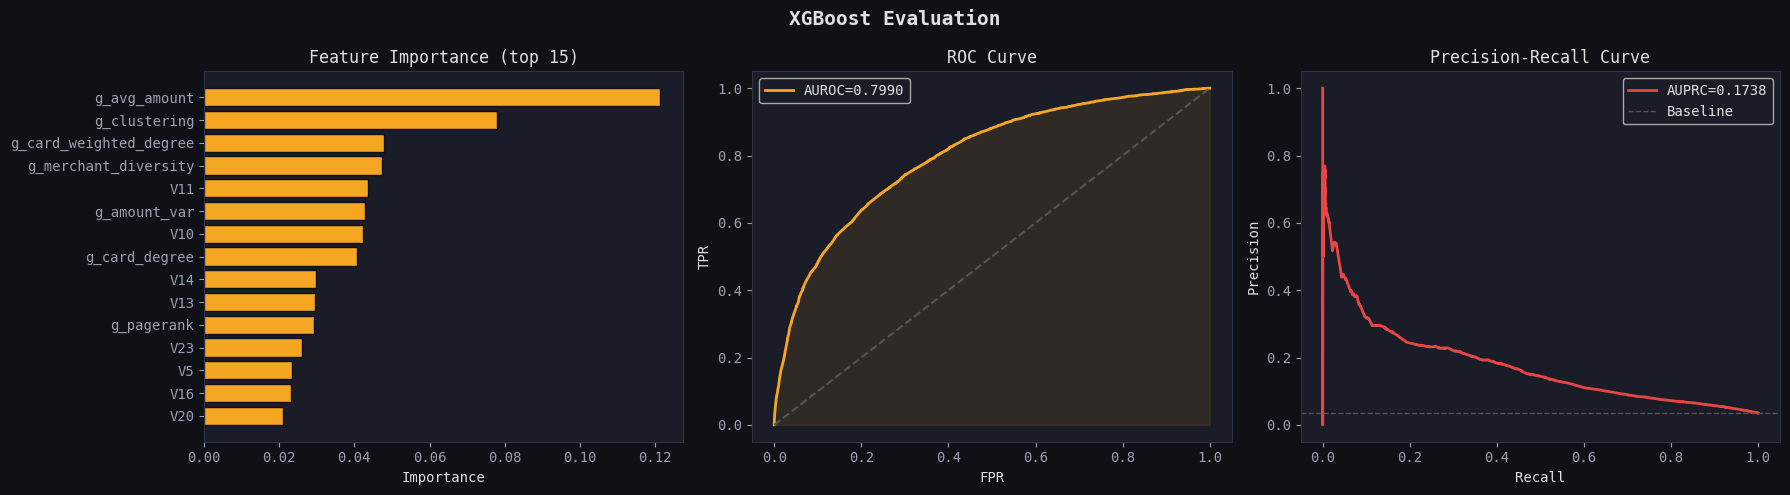

Saved xgb_results.json


In [20]:
importance_df = (
    pd.DataFrame({'feature': FEATURE_NAMES, 'importance': final_clf.feature_importances_})
    .sort_values('importance', ascending=False).reset_index(drop=True)
)
print('Top 15 features:')
print(importance_df.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost Evaluation', fontsize=14, fontweight='bold', color='#E0E0E0')

top15 = importance_df.head(15)
axes[0].barh(top15['feature'][::-1], top15['importance'][::-1],
             color=PAL['accent'], edgecolor='#0F1117')
axes[0].set_title('Feature Importance (top 15)', color='#E0E0E0')
axes[0].set_xlabel('Importance')

fpr, tpr, _ = roc_curve(y_test_full, test_scores)
axes[1].plot(fpr, tpr, color=PAL['accent'], lw=2, label=f'AUROC={auroc:.4f}')
axes[1].plot([0,1],[0,1],'--',color='#555')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=PAL['accent'])
axes[1].set_title('ROC Curve', color='#E0E0E0'); axes[1].legend()
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')

prec, rec, _ = precision_recall_curve(y_test_full, test_scores)
axes[2].plot(rec, prec, color=PAL['fraud'], lw=2, label=f'AUPRC={auprc:.4f}')
axes[2].axhline(y_test_full.mean(), color='#555', ls='--', lw=1, label='Baseline')
axes[2].set_title('Precision-Recall Curve', color='#E0E0E0'); axes[2].legend()
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')

plt.tight_layout()
plt.savefig(OUT_DIR/'model/xgb_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

with open(MDL_DIR/'xgb_results.json', 'w') as f:
    json.dump({'auroc': round(float(auroc),4), 'auprc': round(float(auprc),4),
               'cv_auroc_mean': round(float(np.mean(cv_aurocs)),4),
               'cv_auroc_std' : round(float(np.std(cv_aurocs)),4),
               'n_estimators' : int(best_n), 'device': XGB_DEVICE}, f, indent=2)
print('Saved xgb_results.json')